In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Machine Learning Lab – Experiment 1
## Multiple Linear Regression – Body Weight Prediction

### Aim
To build a Multiple Linear Regression model to predict a person's
body weight using height and gender.

In [2]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# ============================================
# 2. CREATE DATASET
# ============================================

data = {
    "Height": [
        150, 155, 158, 160, 162,
        165, 168, 170, 172, 175,
        178, 180, 182, 185, 188,
        190, 163, 167, 173, 177
    ],

    "Gender": [
        "Female", "Female", "Female", "Female", "Female",
        "Female", "Female", "Male", "Male", "Male",
        "Male", "Male", "Male", "Male", "Male",
        "Male", "Female", "Female", "Male", "Male"
    ],

    "Weight": [
        48, 52, 54, 55, 57,
        59, 61, 65, 68, 72,
        75, 78, 82, 85, 89,
        91, 58, 62, 70, 74
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
display(df.head(10))

Dataset created successfully!


,Height,Gender,Weight
0,150,Female,48
1,155,Female,52
2,158,Female,54
3,160,Female,55
4,162,Female,57
5,165,Female,59
6,168,Female,61
7,170,Male,65
8,172,Male,68
9,175,Male,72


In [4]:
# ============================================
# 3. DATASET INFORMATION
# ============================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (20, 3)

Column Names:
['Height', 'Gender', 'Weight']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Height  20 non-null     int64 
 1   Gender  20 non-null     object
 2   Weight  20 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 612.0+ bytes


In [5]:
# ============================================
# 4. STATISTICAL SUMMARY
# ============================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Height,20.0,170.90,11.116133,150.0,162.75,171.0,178.50,190.0
Weight,20.0,67.75,12.723269,48.0,57.75,66.5,75.75,91.0


In [6]:
# ============================================
# 5. MISSING VALUE ANALYSIS
# ============================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

display(missing_summary)

,Missing Values,Percentage
Height,0,0.0
Gender,0,0.0
Weight,0,0.0


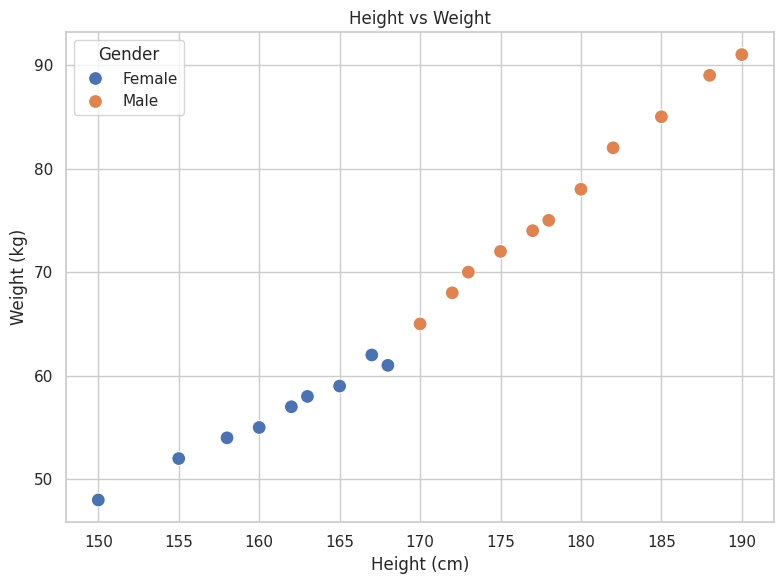

In [7]:
# ============================================
# 6. HEIGHT VS WEIGHT
# ============================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Height",
    y="Weight",
    hue="Gender",
    s=100
)

plt.title("Height vs Weight")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")

plt.tight_layout()
plt.show()

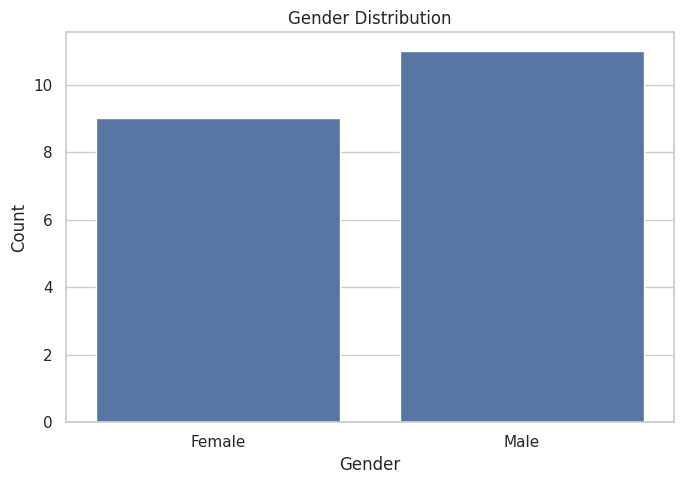

In [8]:
# ============================================
# 7. GENDER DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [9]:
# ============================================
# 8. ENCODE GENDER
# ============================================

df["Gender_Encoded"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

display(df.head())

,Height,Gender,Weight,Gender_Encoded
0,150,Female,48,0
1,155,Female,52,0
2,158,Female,54,0
3,160,Female,55,0
4,162,Female,57,0


,Height,Gender_Encoded,Weight
Height,1.000000,0.835779,0.990794
Gender_Encoded,0.835779,1.000000,0.840833
Weight,0.990794,0.840833,1.000000


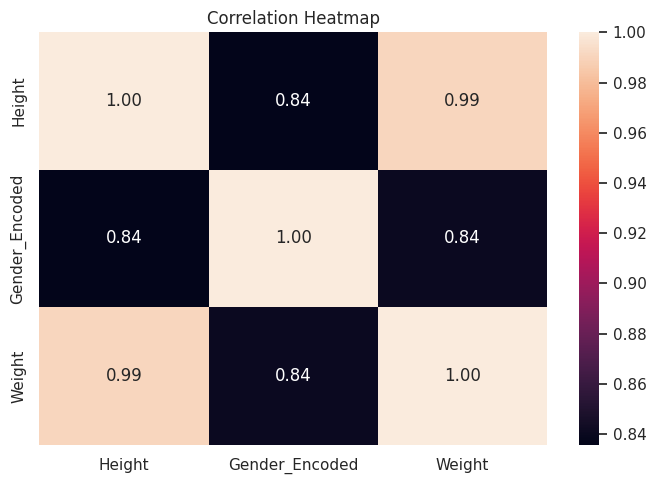

In [10]:
# ============================================
# 9. CORRELATION ANALYSIS
# ============================================

correlation = df[
    ["Height", "Gender_Encoded", "Weight"]
].corr()

display(correlation)

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [11]:
# ============================================
# 10. DEFINE FEATURES AND TARGET
# ============================================

X = df[
    ["Height", "Gender_Encoded"]
]

y = df["Weight"]

print("Independent Variables:")
display(X.head())

print("\nDependent Variable:")
display(y.head())

Independent Variables:


,Height,Gender_Encoded
0,150,0
1,155,0
2,158,0
3,160,0
4,162,0



Dependent Variable:


0    48
1    52
2    54
3    55
4    57
Name: Weight, dtype: int64

In [12]:
# ============================================
# 11. TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 16
Testing samples : 4


In [13]:
# ============================================
# 12. TRAIN MULTIPLE LINEAR REGRESSION
# ============================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Multiple Linear Regression model trained successfully!")

Multiple Linear Regression model trained successfully!


In [14]:
# ============================================
# 13. MODEL COEFFICIENTS
# ============================================

print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(f"{feature}: {coefficient:.4f}")

Intercept: -140.46460980036306

Coefficients:
Height: 1.2160
Gender_Encoded: -0.1782


In [15]:
# ============================================
# 14. MAKE PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Weight": y_test.values,
    "Predicted Weight": y_pred
})

display(results)

,Actual Weight,Predicted Weight
0,48,41.931034
1,62,62.602541
2,91,90.391652
3,52,48.010889


In [16]:
# ============================================
# 15. MODEL EVALUATION
# ============================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("=" * 45)
print("   MULTIPLE LINEAR REGRESSION RESULTS")
print("=" * 45)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

print("=" * 45)

   MULTIPLE LINEAR REGRESSION RESULTS
MAE  : 2.8172
MSE  : 13.3696
RMSE : 3.6564
R²   : 0.9527


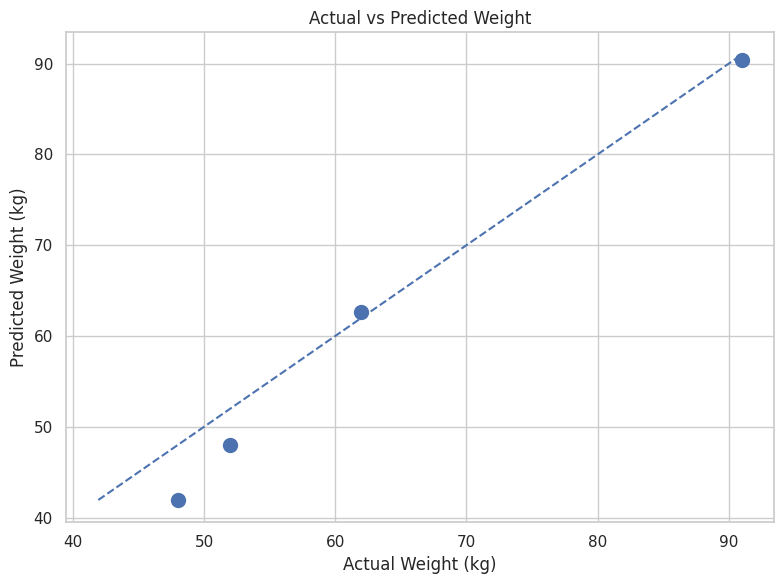

In [17]:
# ============================================
# 16. ACTUAL VS PREDICTED WEIGHT
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    s=100
)

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Weight (kg)")
plt.ylabel("Predicted Weight (kg)")
plt.title("Actual vs Predicted Weight")

plt.tight_layout()
plt.show()

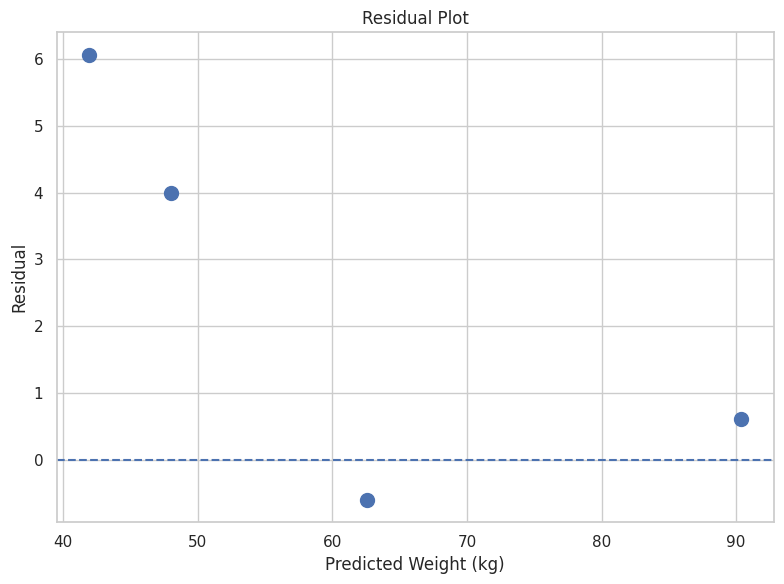

In [18]:
# ============================================
# 17. RESIDUAL ANALYSIS
# ============================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    s=100
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Weight (kg)")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

## Conclusion

A Multiple Linear Regression model was successfully developed to predict
a person's body weight using height and gender as independent variables.

The dataset was created, analyzed, and preprocessed before dividing it
into training and testing datasets. Gender was converted into numerical
form using encoding.

The model was evaluated using Mean Absolute Error (MAE), Mean Squared
Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

Thus, Multiple Linear Regression was successfully applied to predict
body weight from height and gender.